In [2]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [3]:
# Created the SQLite database connection and loaded in the data from the original datasets
try:
    connection = sqlite3.connect("crime_storm_data.db")

    storm_csv = "stormEvents2024.csv"
    crime_csv = "MPDPoliceIncidents2024.csv"

    storm_original = pd.read_csv(storm_csv)
    crime_original = pd.read_csv(crime_csv)

    storm_original.to_sql("storm_events", connection, if_exists="replace", index=False)
    crime_original.to_sql("crime_data", connection, if_exists="replace", index=False)

    print("Successfully loaded data")

except Exception as e:
    print(f"Error loading data: {e}")

Successfully loaded data


In [4]:
# Read storm data and verified results

# Queried the storm events from SQLite
storm_query = """
SELECT BEGIN_DATE_TIME, EVENT_TYPE, CZ_NAME, STATE
FROM storm_events
WHERE STATE = 'FLORIDA' AND CZ_NAME LIKE '%MIAMI%'
AND BEGIN_DATE_TIME IS NOT NULL AND EVENT_TYPE IS NOT NULL
"""

storm_df = pd.read_sql_query(storm_query, connection)
# Print results
storm_df

,BEGIN_DATE_TIME,EVENT_TYPE,CZ_NAME,STATE
0,04-FEB-24 11:32:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA
1,04-FEB-24 10:47:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA
2,04-FEB-24 11:20:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA
3,22-MAR-24 20:15:00,Flood,MIAMI-DADE,FLORIDA
4,06-MAR-24 05:45:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA
5,21-MAY-24 15:00:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA
6,21-MAY-24 15:46:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA
7,29-MAY-24 15:50:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA
8,21-MAY-24 14:40:00,Hail,MIAMI-DADE,FLORIDA
9,21-MAY-24 14:46:00,Thunderstorm Wind,MIAMI-DADE,FLORIDA


In [5]:
# Read in crime data and verified results

# Queried the crime data from SQLite
crime_query = """
SELECT CFSDATE, IncidentType, `ZIP Code`
FROM crime_data
WHERE CFSDATE IS NOT NULL
AND `ZIP Code` IS NOT NULL AND `ZIP Code` != ''
"""

crime_df = pd.read_sql_query(crime_query, connection)
# Print results
crime_df

,CFSDate,IncidentType,ZIP Code
0,2024-12-09 14:14:30.610,"17M - ACCIDENT, MINOR",33147.0
1,2024-12-09 14:19:02.717,34 - DISTURBANCE,33135.0
2,2024-12-09 14:40:56.363,34 - DISTURBANCE,33150.0
3,2024-12-09 14:55:37.963,13 - CONDUCT INVESTIGATION,33126.0
4,2024-12-09 14:59:41.250,13 - CONDUCT INVESTIGATION,33127.0
...,...,...,...
314593,2024-12-10 19:53:20.787,13 - CONDUCT INVESTIGATION,33150.0
314594,2024-12-10 19:53:01.033,19 - TRAFFIC VIOLATION,33129.0
314595,2024-12-10 18:54:49.410,"17M - ACCIDENT, MINOR",33135.0
314596,2024-12-10 19:17:41.800,19 - TRAFFIC VIOLATION,33128.0


In [6]:
# Cleaned data for merging 
storm_df['BEGIN_DATE_TIME'] = pd.to_datetime(storm_df['BEGIN_DATE_TIME']).dt.date
crime_df['CFSDate'] = pd.to_datetime(crime_df['CFSDate']).dt.date

C:\Users\anaxz\AppData\Local\Temp\ipykernel_10852\1778012199.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  storm_df['BEGIN_DATE_TIME'] = pd.to_datetime(storm_df['BEGIN_DATE_TIME']).dt.date


In [7]:
# Removed the rows that contain missing values for more accurate merging
storm_df = storm_df.dropna()
crime_df = crime_df.dropna()

In [8]:
# Filter data to only include relevent crime incidents 
crime_df = crime_df[
    crime_df['IncidentType'].str.contains('LARCENY|BURGLARY|VEHICLE|VANDAL',
                                          case=False,
                                          na=False)
]
# Exclude values containing recovery and suspicious
crime_df = crime_df[
    ~crime_df['IncidentType'].str.contains('RECOVERY | SUSPIC',
                                          case=False,
                                          na=False)
]

In [9]:
# Print property top 10 property crime and storm events verifying the filtering results
print(crime_df['IncidentType'].value_counts().head(10))
print(storm_df['EVENT_TYPE'].value_counts().head(10))

IncidentType
27 - LARCENY THEFT                     3543
27V - LARCENY THEFT - MOTOR VEHICLE    3370
27R - LARCENY THEFT – RETAIL           2607
28 - VANDALISM                         2299
22 - STOLEN VEHICLE                    2057
26 - BURGLARY                          1233
26O - BURGLARY - OCCUPIED               163
26I - BURGLARY - IN PROGRESS             17
Name: count, dtype: int64
EVENT_TYPE
Thunderstorm Wind      12
Flood                   9
Tropical Depression     9
Hail                    3
Coastal Flood           3
Tornado                 3
Flash Flood             2
Tropical Storm          2
Strong Wind             1
Name: count, dtype: int64


In [10]:
# Merge storm and crime datasets using dates that match
merged_df = pd.merge(
storm_df,
crime_df,
left_on='BEGIN_DATE_TIME',
right_on='CFSDate',
how='inner'
)

merged_df

,BEGIN_DATE_TIME,EVENT_TYPE,CZ_NAME,STATE,CFSDate,IncidentType,ZIP Code
0,2024-02-04,Thunderstorm Wind,MIAMI-DADE,FLORIDA,2024-02-04,27V - LARCENY THEFT - MOTOR VEHICLE,33135.0
1,2024-02-04,Thunderstorm Wind,MIAMI-DADE,FLORIDA,2024-02-04,22 - STOLEN VEHICLE,33132.0
2,2024-02-04,Thunderstorm Wind,MIAMI-DADE,FLORIDA,2024-02-04,27 - LARCENY THEFT,33130.0
3,2024-02-04,Thunderstorm Wind,MIAMI-DADE,FLORIDA,2024-02-04,27 - LARCENY THEFT,33131.0
4,2024-02-04,Thunderstorm Wind,MIAMI-DADE,FLORIDA,2024-02-04,27V - LARCENY THEFT - MOTOR VEHICLE,33136.0
...,...,...,...,...,...,...,...
1811,2024-02-18,Tornado,MIAMI-DADE,FLORIDA,2024-02-18,27R - LARCENY THEFT – RETAIL,33142.0
1812,2024-02-18,Tornado,MIAMI-DADE,FLORIDA,2024-02-18,28 - VANDALISM,33126.0
1813,2024-02-18,Tornado,MIAMI-DADE,FLORIDA,2024-02-18,26 - BURGLARY,33131.0
1814,2024-02-18,Tornado,MIAMI-DADE,FLORIDA,2024-02-18,27R - LARCENY THEFT – RETAIL,33131.0


In [11]:
# Count the number of property crimes and the events associated with those events
event_counts = merged_df['EVENT_TYPE'].value_counts()
event_counts

EVENT_TYPE
Thunderstorm Wind      511
Tropical Depression    411
Flood                  342
Hail                   129
Coastal Flood          118
Tornado                104
Tropical Storm          88
Flash Flood             76
Strong Wind             37
Name: count, dtype: int64

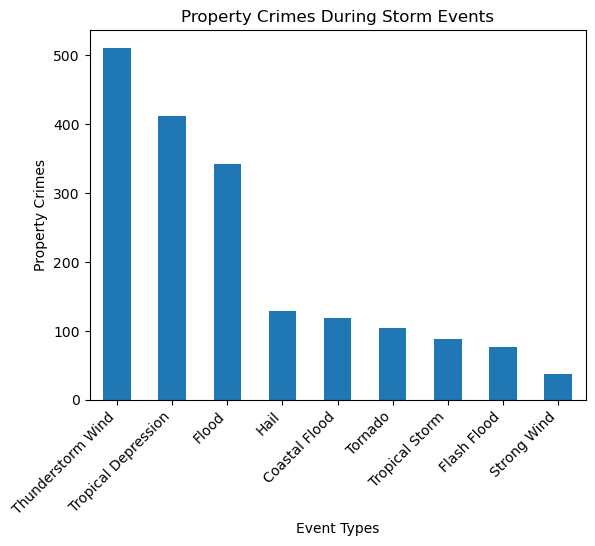

In [12]:
# Create a bar chart that shows the number of property crimes during storm events
event_counts.plot(kind='bar')
# Include chart title and labels
plt.title("Property Crimes During Storm Events")
plt.xlabel("Event Types")
plt.ylabel("Property Crimes")
plt.xticks(rotation=45, ha='right')

plt.savefig("DAT 375 Project Two_Visualization_Jonathan Hodge.png")
plt.show()

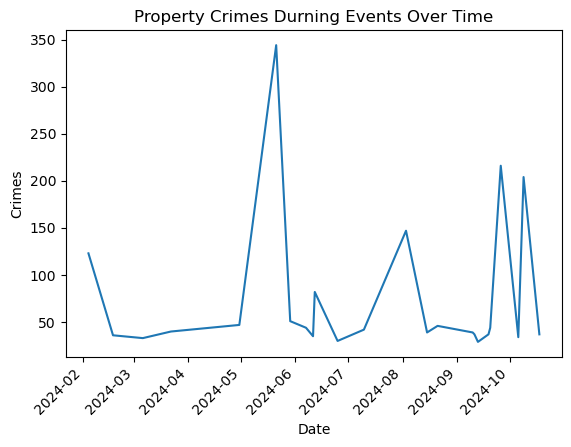

In [13]:
# Create a line chart that shows the number of property crimes during storm events over time
merged_df['CFSDate'] = pd.to_datetime(merged_df['CFSDate'])

time_frame = merged_df.groupby('CFSDate').size()

# Chart title and lables
time_frame.plot(kind='line')
plt.title("Property Crimes Durning Events Over Time")
plt.xlabel("Date")
plt.ylabel("Crimes")

plt.xticks(rotation=45, ha='right')

plt.savefig("DAT 375 Project Two_Second_Visualization_Jonathan Hodge.png")
plt.show()

In [14]:
# Save csv
merged_df.to_csv("DAT 375 ProjectTwo_Visualization_Enhanced_Jonathan Hodge.csv", index=False, encoding='utf-8-sig')